In [1]:
import os, json
import numpy as np
import cv2
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (10,4)

# EDIT THESE
DEPTH_NPY = r"C:\Users\admin\Documents\Vicki\School stuff\SEGP\exports\depth_all\frames\000000_depth_m.npy"
CAM_JSON  = r"C:\Users\admin\Documents\Vicki\School stuff\SEGP\exports\depth_all\meta\camera.json"

depth = np.load(DEPTH_NPY).astype(np.float32)
with open(CAM_JSON, "r") as f:
    cam = json.load(f)

fx, fy, cx, cy = cam["fx"], cam["fy"], cam["cx"], cam["cy"]
H, W = depth.shape
print("depth:", depth.shape, "fx,fy,cx,cy:", fx, fy, cx, cy)


depth: (480, 848) fx,fy,cx,cy: 432.076416015625 432.076416015625 425.9288635253906 241.88552856445312


In [2]:
def depth_preview(depth, vmin=None, vmax=None):
    d = depth.copy()
    d[~np.isfinite(d)] = 0
    if vmin is None or vmax is None:
        vals = d[d>0]
        if vals.size:
            vmin, vmax = np.percentile(vals, [2,98])
        else:
            vmin, vmax = 0, 1
    d = np.clip((d-vmin)/(vmax-vmin+1e-9), 0, 1)
    d8 = (d*255).astype(np.uint8)
    return cv2.applyColorMap(d8, cv2.COLORMAP_TURBO)  # just for viewing

def xy_rays(H, W, fx, fy, cx, cy):
    xs = (np.arange(W) - cx)/fx
    ys = (np.arange(H) - cy)/fy
    return np.meshgrid(xs, ys)  # X1, Y1 (HxW)


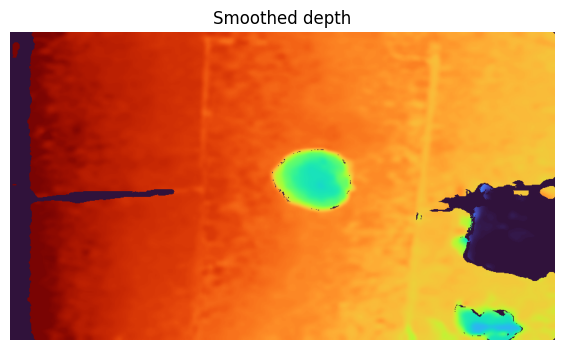

In [3]:
# bilateral filter preserves edges, reduces speckle
depth_s = cv2.bilateralFilter(depth, d=7, sigmaColor=0.07, sigmaSpace=7)
prev = depth_preview(depth_s)
plt.imshow(cv2.cvtColor(prev, cv2.COLOR_BGR2RGB)); plt.title("Smoothed depth"); plt.axis('off'); plt.show()


In [4]:
X1, Y1 = xy_rays(H, W, fx, fy, cx, cy)
valid = np.isfinite(depth_s) & (depth_s > 0.2) & (depth_s < 5.0)

# sample up to 50k pixels for speed
idx = np.flatnonzero(valid)
if idx.size > 50000:
    idx = np.random.choice(idx, 50000, replace=False)

Zs = depth_s.ravel()[idx]
Xs = (X1.ravel()[idx]) * Zs
Ys = (Y1.ravel()[idx]) * Zs

# robust LS: 2 iterations with outlier rejection (Tukey-like)
def fit_plane_LS(X, Y, Z):
    A = np.c_[X, Y, np.ones_like(X)]
    sol, *_ = np.linalg.lstsq(A, Z, rcond=None)
    return sol  # a,b,c s.t. Z ≈ aX + bY + c

a,b,c = fit_plane_LS(Xs, Ys, Zs)
res = Zs - (a*Xs + b*Ys + c)
sigma = 1.4826*np.median(np.abs(res - np.median(res))) + 1e-9
keep = np.abs(res) < 3*sigma
a,b,c = fit_plane_LS(Xs[keep], Ys[keep], Zs[keep])

print(f"Plane: Z = {a:.4f}*X + {b:.4f}*Y + {c:.4f}  | kept {keep.sum()}/{len(keep)} samples")


Plane: Z = -0.0605*X + -0.0167*Y + 1.5583  | kept 46114/50000 samples


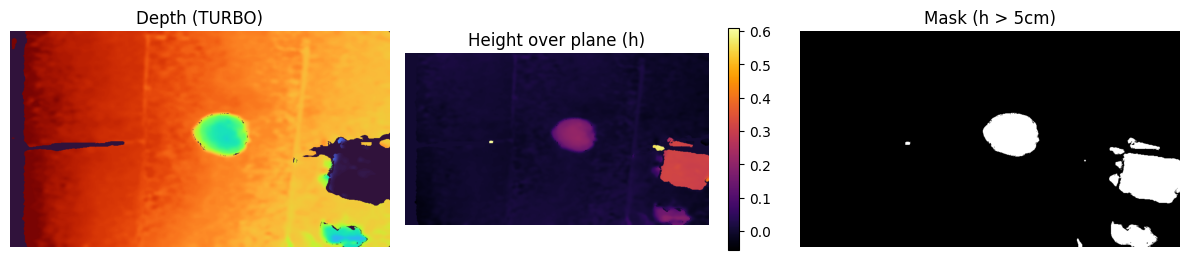

In [5]:
# Fit plane already done
Zp = a*(X1*depth_s) + b*(Y1*depth_s) + c  # plane at each pixel
h  = Zp - depth_s                         # height above plane
h[~valid] = 0                             # invalid depth set to 0

# ✅ Apply threshold
mask = (h > 0.05)   # only keep pixels at least 5cm above plane

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Depth (TURBO)")
plt.imshow(cv2.cvtColor(prev, cv2.COLOR_BGR2RGB)); plt.axis('off')

plt.subplot(1,3,2); plt.title("Height over plane (h)")
plt.imshow(h, cmap='inferno'); plt.colorbar(shrink=0.6); plt.axis('off')

plt.subplot(1,3,3); plt.title("Mask (h > 5cm)")
plt.imshow(mask.astype(np.uint8)*255, cmap='gray'); plt.axis('off')

plt.tight_layout(); plt.show()


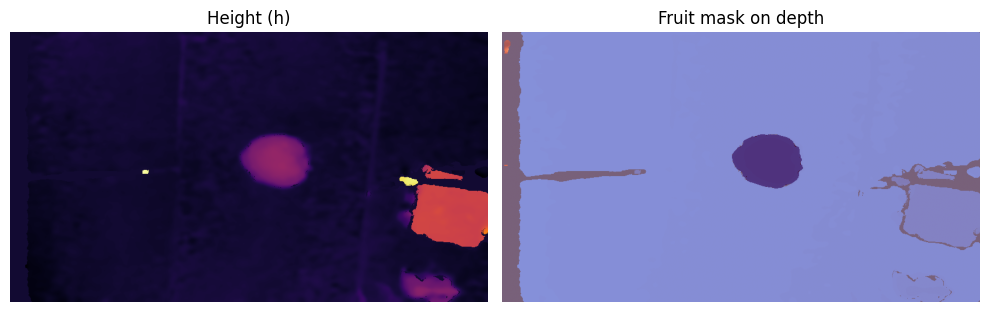

Fruit pixels: 9082


In [6]:
# === Keep only the fruit blob (central, compact) ===

H, W = h.shape
m8 = (mask.astype(np.uint8) * 255)

# erase anything touching the image borders (rails/edge)
border = np.zeros_like(m8); border[[0,-1],:] = 255; border[:,[0,-1]] = 255
border = cv2.dilate(border, cv2.getStructuringElement(cv2.MORPH_RECT,(9,9)))
m8[border>0] = 0

# clean & close
m8 = cv2.morphologyEx(m8, cv2.MORPH_OPEN,  cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5)))
m8 = cv2.morphologyEx(m8, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(11,11)))

num, lab, stats, cents = cv2.connectedComponentsWithStats(m8, connectivity=8)

best = None; best_score = -1
for k in range(1, num):  # skip background 0
    area = stats[k, cv2.CC_STAT_AREA]
    if area < 1500:          # ignore small specks
        continue
    cx_i, cy_i = cents[k]
    # centrality (tighten if right blob still survives)
    if not (W*0.25 < cx_i < W*0.75 and H*0.25 < cy_i < H*0.75):
        continue
    # compactness (reject skinny shapes)
    ys, xs = np.where(lab==k)
    X = np.c_[xs, ys].astype(np.float32)
    X -= X.mean(0, keepdims=True)
    cov = (X.T @ X) / max(1, len(X)-1)
    w, _ = np.linalg.eigh(cov)
    elong = np.sqrt(max(w)) / (np.sqrt(min(w))+1e-9)
    if elong > 5.0:
        continue
    # score by area / distance to image center
    d = np.hypot(cx_i - W/2, cy_i - H/2) + 1e-6
    score = area / d
    if score > best_score:
        best_score = score; best = k

fruit_mask = (lab==best).astype(np.uint8) if best is not None else np.zeros_like(m8)

# quick visual check (optional)
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.title("Height (h)"); plt.imshow(h, cmap='inferno'); plt.axis('off')
plt.subplot(1,2,2); plt.title("Fruit mask on depth")
plt.imshow(depth_s, cmap='turbo'); plt.imshow(fruit_mask, alpha=0.35, cmap='Reds'); plt.axis('off')
plt.tight_layout(); plt.show()

print("Fruit pixels:", int(fruit_mask.sum()))


In [7]:
fx, fy, cx, cy = cam["fx"], cam["fy"], cam["cx"], cam["cy"]

# pixel footprint ~ (Z_plane^2)/(fx*fy)
ys, xs = np.where(fruit_mask > 0)
Zp_ = (a*( (xs-cx)/fx * depth_s[ys, xs] ) +
       b*( (ys-cy)/fy * depth_s[ys, xs] ) + c)         # plane depth at those pixels

h_ = (Zp_ - depth_s[ys, xs])                           # height over plane (positive on fruit)
h_[h_ < 0] = 0

area_px = (Zp_**2) / (fx*fy)                           # m^2 per pixel
V_25D   = float(np.sum(h_ * area_px))                  # m^3

# quick sanity
print(f"pixels={len(h_)}, mean h={h_.mean():.4f} m, max h={h_.max():.4f} m")
print(f"2.5D volume = {V_25D:.6f} m^3")

# convert to mass
DENSITY = 956.28   # kg/m^3 gotten the density from the thesis page 68
mass = DENSITY * V_25D
print(f"Estimated mass ≈ {mass:.2f} kg")


pixels=9082, mean h=0.1678 m, max h=1.5583 m
2.5D volume = 0.019617 m^3
Estimated mass ≈ 18.76 kg
